In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
print("Loading dataset...")

df = pd.read_csv('driftcatch.csv')

# Drop any rows where the prompt or label might be missing to prevent training errors
df = df.dropna(subset=['prompt', 'label'])


Loading dataset...


In [3]:
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'semantic_risk_score',
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])


In [6]:
models = {
    "Linear Regression (Thresholded)": LinearRegression(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

In [7]:
print("\nCommencing Model Training...\n" + "="*30)

for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    
    # Bundle the preprocessor and the specific model into a single Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Predict on the unseen testing data
    predictions = pipeline.predict(X_test)
    
    # Since Linear Regression outputs continuous values (e.g., 0.3, 0.8), 
    # we must snap them to 0 or 1 using a 0.5 threshold to calculate accuracy.
    if name == "Linear Regression (Thresholded)":
        predictions = np.where(predictions >= 0.5, 1, 0)
        
    # Calculate Metrics
    acc = accuracy_score(y_test, predictions)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, predictions))
    


Commencing Model Training...

--- Training: Linear Regression (Thresholded) ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       1.00      1.00      1.00       211

    accuracy                           1.00       421
   macro avg       1.00      1.00      1.00       421
weighted avg       1.00      1.00      1.00       421


--- Training: Logistic Regression ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       1.00      1.00      1.00       211

    accuracy                           1.00       421
   macro avg       1.00      1.00      1.00       421
weighted avg       1.00      1.00      1.00       421


--- Training: Random Forest Classifier ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

       

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (REMOVING THE DATA LEAK: 'semantic_risk_score')
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Initialize Constrained Random Forest (Prevents Overfitting)
# - max_depth=5: Stops the trees from getting too complex and memorizing data
# - min_samples_leaf=2: Ensures terminal nodes have enough data to be statistically significant
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_leaf=2, 
    random_state=42, 
    n_jobs=-1
)

# 6. Build and Train Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

print("Training Random Forest...")
pipeline.fit(X_train, y_train)

# 7. Evaluate for Overfitting/Underfitting
train_preds = pipeline.predict(X_train)
test_preds = pipeline.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"\n--- Model Evaluation ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

# If Train and Test accuracy are close to each other, the model is perfectly balanced.
if abs(train_acc - test_acc) < 0.05:
    print("Diagnosis: Model is well-balanced (Neither overfit nor underfit).")
else:
    print("Diagnosis: Model shows signs of overfitting.")

print("\n--- Detailed Test Classification Report ---")
print(classification_report(y_test, test_preds))

Training Random Forest...

--- Model Evaluation ---
Training Accuracy: 0.9762
Testing Accuracy:  0.9810
Diagnosis: Model is well-balanced (Neither overfit nor underfit).

--- Detailed Test Classification Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       210
           1       1.00      0.96      0.98       211

    accuracy                           0.98       421
   macro avg       0.98      0.98      0.98       421
weighted avg       0.98      0.98      0.98       421



In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (Excluding the leaky 'semantic_risk_score')
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 6. Build and Train Pipeline
pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

print("Training Logistic Regression...")
pipeline_log.fit(X_train, y_train)

# 7. Evaluate Model
predictions = pipeline_log.predict(X_test)
acc = accuracy_score(y_test, predictions)

print(f"\nLogistic Regression Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, predictions))

Training Logistic Regression...

Logistic Regression Accuracy: 0.9810
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       210
           1       1.00      0.97      0.98       211

    accuracy                           0.98       421
   macro avg       0.98      0.98      0.98       421
weighted avg       0.98      0.98      0.98       421



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (Excluding the leaky 'semantic_risk_score')
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Initialize Linear Regression
lin_reg = LinearRegression()

# 6. Build and Train Pipeline
pipeline_lin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lin_reg)
])

print("Training Linear Regression...")
pipeline_lin.fit(X_train, y_train)

# 7. Evaluate Model (Applying the 0.5 Threshold)
raw_predictions = pipeline_lin.predict(X_test)
# Convert continuous predictions into binary 0 or 1
discrete_predictions = np.where(raw_predictions >= 0.5, 1, 0)

acc = accuracy_score(y_test, discrete_predictions)

print(f"\nLinear Regression Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, discrete_predictions))

Training Linear Regression...

Linear Regression Accuracy: 0.9691
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       210
           1       0.98      0.96      0.97       211

    accuracy                           0.97       421
   macro avg       0.97      0.97      0.97       421
weighted avg       0.97      0.97      0.97       421



Training models and calculating accuracies...

Linear Regression -> Train Acc: 1.0000 | Test Acc: 0.9691
Logistic Regression -> Train Acc: 0.9923 | Test Acc: 0.9810
Random Forest -> Train Acc: 0.9762 | Test Acc: 0.9810


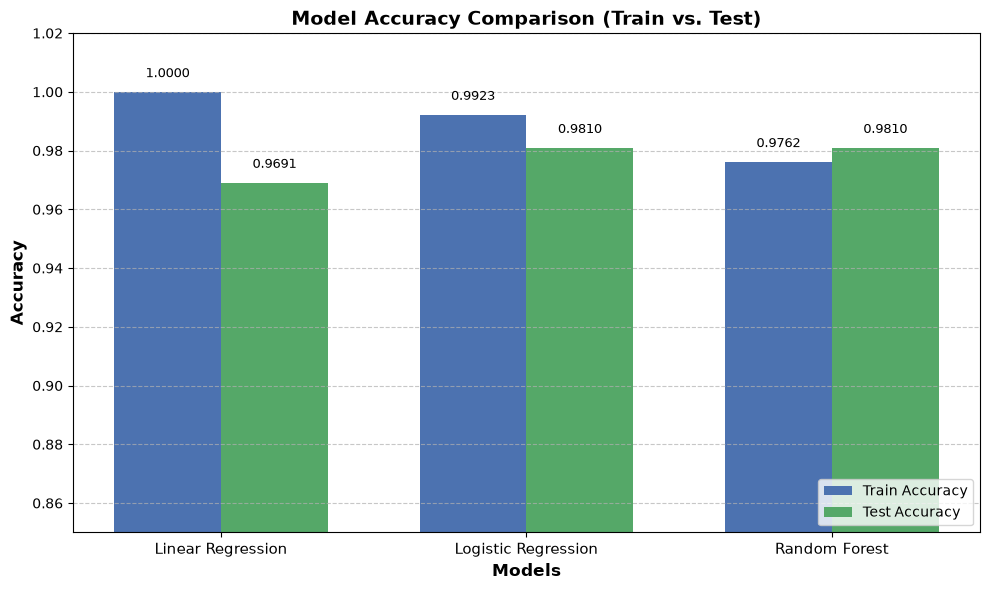

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Define All Models in a Dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
}

# List to hold our metric results
results = []

print("Training models and calculating accuracies...\n")

# 6. Train, Predict, and Record Scores for Each Model
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Make Predictions
    raw_train_preds = pipeline.predict(X_train)
    raw_test_preds = pipeline.predict(X_test)
    
    # Apply Threshold to Linear Regression outputs
    if name == 'Linear Regression':
        train_preds = np.where(raw_train_preds >= 0.5, 1, 0)
        test_preds = np.where(raw_test_preds >= 0.5, 1, 0)
    else:
        train_preds = raw_train_preds
        test_preds = raw_test_preds
        
    # Calculate Accuracy
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    # Save Results
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    
    print(f"{name} -> Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# Convert results into a DataFrame for easy handling
results_df = pd.DataFrame(results)


plt.figure(figsize=(10, 6))
x = np.arange(len(results_df['Model']))
width = 0.35

# Plot Train and Test Accuracies side-by-side
bars1 = plt.bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy', color='#4C72B0')
bars2 = plt.bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy', color='#55A868')

# Formatting the Chart
plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Accuracy', fontweight='bold', fontsize=12)
plt.title('Model Accuracy Comparison (Train vs. Test)', fontweight='bold', fontsize=14)
plt.xticks(x, results_df['Model'], fontsize=11)
plt.ylim(0.85, 1.02) # Zooming in on the Y-axis so differences are visible
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate exact accuracy values on top of the bars
for i in range(len(results_df)):
    plt.text(i - width/2, results_df['Train Accuracy'][i] + 0.005, f"{results_df['Train Accuracy'][i]:.4f}", ha='center', fontsize=9)
    plt.text(i + width/2, results_df['Test Accuracy'][i] + 0.005, f"{results_df['Test Accuracy'][i]:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
import plotly.io as pio
pio.renderers.default = 'vscode'
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (No semantic_risk_score to prevent data leakage)
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Define All Models
models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
}

# List to hold metric results
results = []

print("Training models and calculating accuracies...\n")
print("-" * 50)

# 6. Train, Predict, and Record Scores for Each Model
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Make Predictions
    raw_train_preds = pipeline.predict(X_train)
    raw_test_preds = pipeline.predict(X_test)
    
    # Apply 0.5 Threshold to Linear Regression outputs
    if name == 'Linear Regression':
        train_preds = np.where(raw_train_preds >= 0.5, 1, 0)
        test_preds = np.where(raw_test_preds >= 0.5, 1, 0)
    else:
        train_preds = raw_train_preds
        test_preds = raw_test_preds
        
    # Calculate Accuracy
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    # Save Results
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    
    print(f"{name:<20} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("-" * 50)

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# ==========================================
# 7. Generate Interactive Visualization (Plotly)
# ==========================================
fig = go.Figure()

# Add Training Accuracy Bars
fig.add_trace(go.Bar(
    x=results_df['Model'],
    y=results_df['Train Accuracy'],
    name='Train Accuracy',
    marker_color='#4C72B0',
    text=results_df['Train Accuracy'].round(4),
    textposition='auto'
))

# Add Testing Accuracy Bars
fig.add_trace(go.Bar(
    x=results_df['Model'],
    y=results_df['Test Accuracy'],
    name='Test Accuracy',
    marker_color='#55A868',
    text=results_df['Test Accuracy'].round(4),
    textposition='auto'
))

# Update Layout and Styling
fig.update_layout(
    title=dict(text='Model Accuracy Comparison: Proactive Intent Firewall', font=dict(size=20)),
    xaxis_title=dict(text='Intent Classification Models', font=dict(size=14)),
    yaxis_title=dict(text='Accuracy Score', font=dict(size=14)),
    barmode='group',
    yaxis=dict(range=[0.85, 1.05]), # Set Y-axis constraints for visibility
    legend=dict(x=0.85, y=0.05),
    plot_bgcolor='white'
)

# Add grid lines
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

# Display the interactive plot
fig.show(renderer="browser")

Training models and calculating accuracies...

--------------------------------------------------
Linear Regression    | Train Acc: 1.0000 | Test Acc: 0.9691
Logistic Regression  | Train Acc: 0.9923 | Test Acc: 0.9810
Random Forest        | Train Acc: 0.9762 | Test Acc: 0.9810
--------------------------------------------------


In [13]:
import joblib
joblib.dump(pipeline, 'firewall_model.pkl')

['firewall_model.pkl']

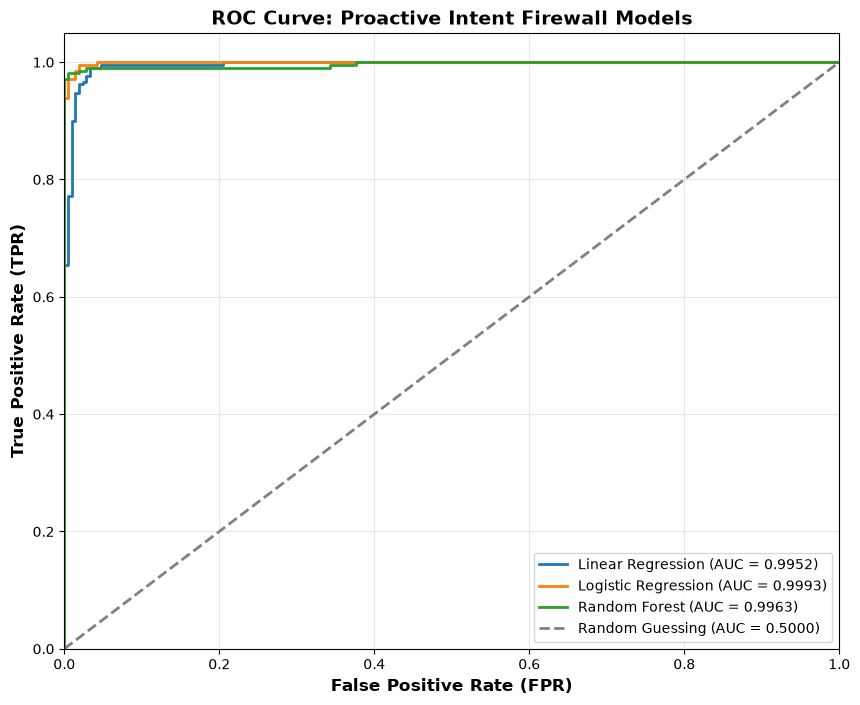

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (Excluding semantic_risk_score)
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Define All Models
models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
}

# 6. Initialize Plot
plt.figure(figsize=(10, 8))

# 7. Train, Predict Probabilities, and Plot for Each Model
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train Model
    pipeline.fit(X_train, y_train)
    
    # Extract prediction scores
    # Linear Regression natively outputs a continuous score, while classifiers use predict_proba
    if name == 'Linear Regression':
        y_scores = pipeline.predict(X_test)
    else:
        # Get probability estimates for the positive class (Adversarial/1)
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        
    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and Thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    
    # Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this specific model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# 8. Format the ROC Chart
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontweight='bold', fontsize=12)
plt.title('ROC Curve: Proactive Intent Firewall Models', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Display the plot inline
plt.show()

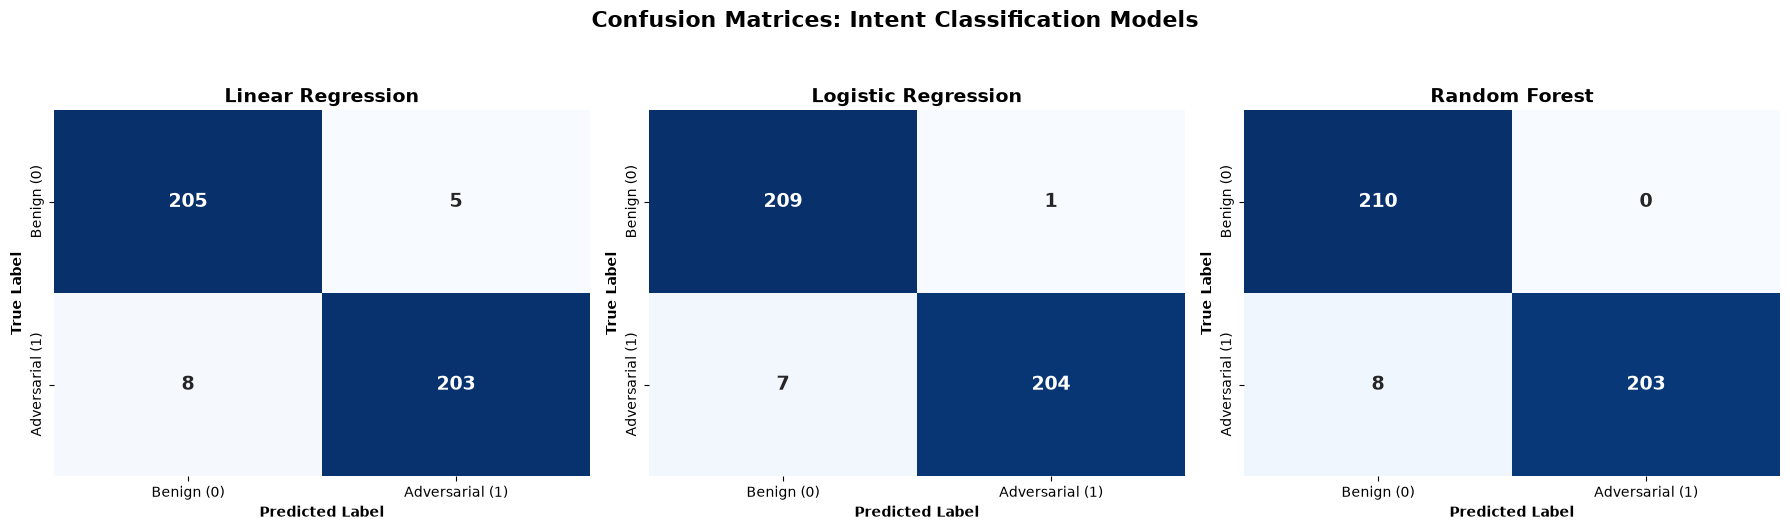

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# 1. Load Dataset
df = pd.read_csv('driftcatch.csv')
df = df.dropna(subset=['prompt', 'label'])

# 2. Define Features (No semantic_risk_score)
text_feature = 'prompt'
numeric_features = [
    'roleplay_indicator', 
    'system_prompt_ref', 
    'jailbreak_keyword_score', 
    'word_count',
    'char_count'
]

X = df[[text_feature] + numeric_features]
y = df['label']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), text_feature),
        ('num', StandardScaler(), numeric_features)
    ])

# 5. Define All Models
models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
}

# 6. Set up the visual grid (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Intent Classification Models', fontsize=16, fontweight='bold', y=1.05)

# 7. Train, Predict, and Plot
for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    
    # Apply Threshold to Linear Regression
    if name == 'Linear Regression':
        preds = np.where(pipeline.predict(X_test) >= 0.5, 1, 0)
    else:
        preds = pipeline.predict(X_test)
        
    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    
    # Plot using Seaborn Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14, "weight": "bold"},
                xticklabels=['Benign (0)', 'Adversarial (1)'],
                yticklabels=['Benign (0)', 'Adversarial (1)'])
    
    # Formatting
    ax.set_title(name, fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')

plt.tight_layout()
plt.show()